## Adabost Hyperparameter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

###  Generate Dataset

Use `make_circles` to create a binary classification problem with two
interleaved circles. This is intentionally non-linearly separable, which makes
it a good stress test for ensemble methods.

- `factor`: controls the radius ratio between the inner and outer circle (smaller = harder)
- `noise`: adds Gaussian noise to the coordinates

In [3]:
np.random.seed(42)

X, y = make_circles(
    n_samples=500,   # 500 data points total
    factor=0.1,      # inner circle is 10% the radius of the outer — very tight
    noise=0.35,      # moderate noise; makes boundary fuzzy
    random_state=42
)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {np.bincount(y)}")  

Dataset shape: X=(500, 2), y=(500,)
Class distribution: [250 250]


### Scatter Plot for dataset 

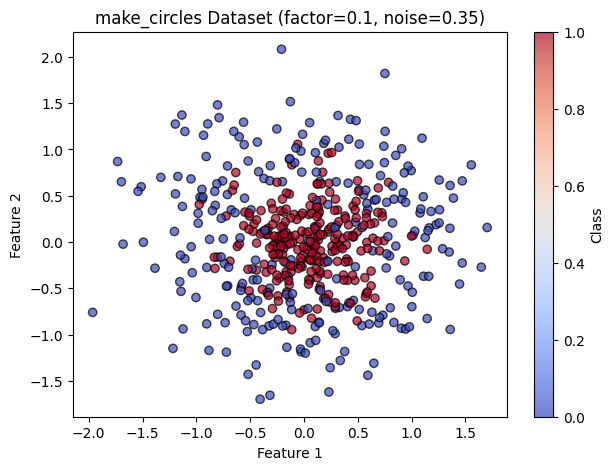

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title("make_circles Dataset (factor=0.1, noise=0.35)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")
plt.show()

### Baseline AdaBoost Model

Train the default AdaBoostClassifier with no hyperparameter changes.
- Default settings: 
- 50 estimators
- learning_rate=1.0
- algorithm='SAMME.R'


In [5]:
adaboost_classifier = AdaBoostClassifier()  # all defaults
adaboost_classifier.fit(X, y)


baseline_acc = accuracy_score(y, adaboost_classifier.predict(X))
print(f"Baseline training accuracy: {baseline_acc:.4f}")

Baseline training accuracy: 0.8540


### Decision Boundary Visualization

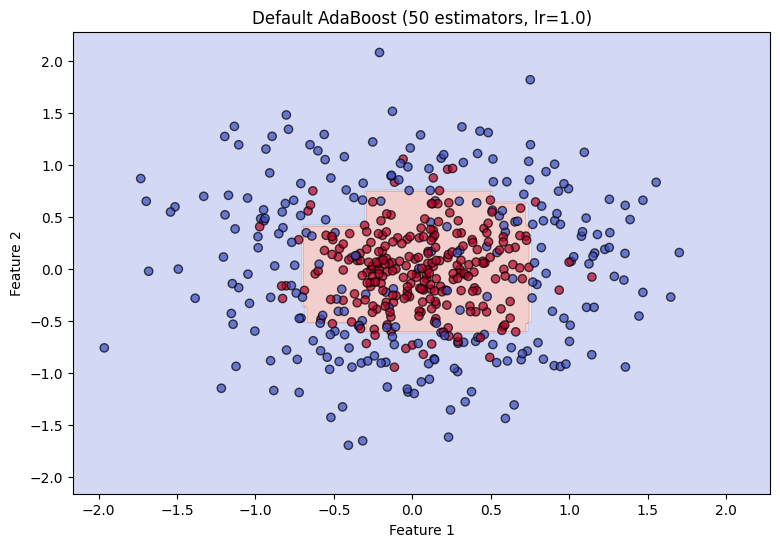

In [6]:
def plot_decision_boundary(clf, title="Adaboost Classifier"):
    """
    Visualizes the decision boundary of a fitted classifier on the global X, y.
    Parameters
    ----------
    clf   : fitted sklearn classifier
    title : string label for the plot title

    """
    plt.figure(figsize=(9, 6))
    x_range = np.linspace(X.min() - 0.2, X.max() + 0.2, 200)  
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(adaboost_classifier, title="Default AdaBoost (50 estimators, lr=1.0)")

### Manual Hyperparameter Experiment

- Manually try a much larger ensemble (1500 estimators) with a lower learning rate (0.1).
- A lower learning rate shrinks each tree's contribution, requiring more trees to compensate.
- This trades speed for potentially smoother generalization.

Large ensemble training accuracy: 0.8520


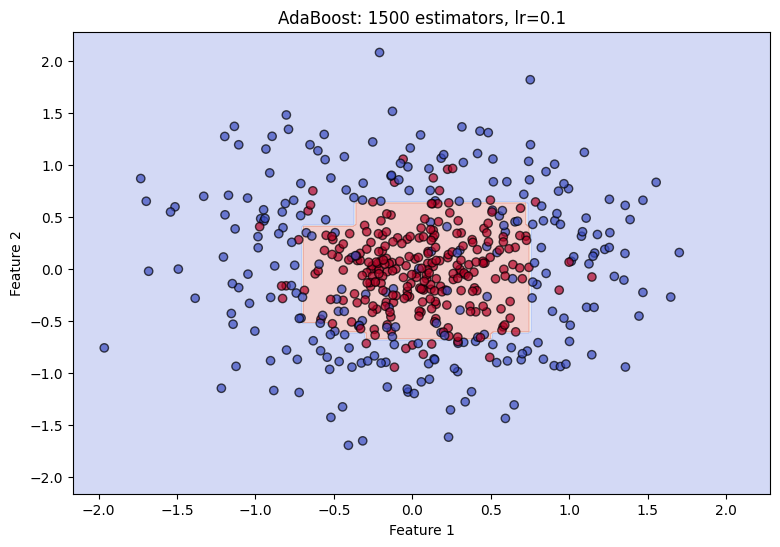

In [7]:
adaboost_large = AdaBoostClassifier(n_estimators=1500, learning_rate=0.1)
adaboost_large.fit(X, y)

large_acc = accuracy_score(y, adaboost_large.predict(X))
print(f"Large ensemble training accuracy: {large_acc:.4f}")

plot_decision_boundary(adaboost_large, title="AdaBoost: 1500 estimators, lr=0.1")

### Hyperparameter Search with GridSearchCV
- `n_estimators`  : number of weak learners (stumps) to chain
- `learning_rate` : shrinks each tree's vote; lower = slower but often more robust
- `algorithm`     : SAMME uses discrete class votes; SAMME.R uses probability estimates (usually better)
- `random_state`  : controls reproducibility

cv=10 means 10-fold cross validation is used at each parameter combination.

In [13]:
grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['random_state'] = [22, 32, 42, 52]

grid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')
grid_result = grid_search.fit(X, y)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.832000 using {'learning_rate': 0.1, 'n_estimators': 500, 'random_state': 22}


### Model - AdaAdaBoostClassifier() According gridSearchCV

adabost_classifier2 training accuracy: 0.8500


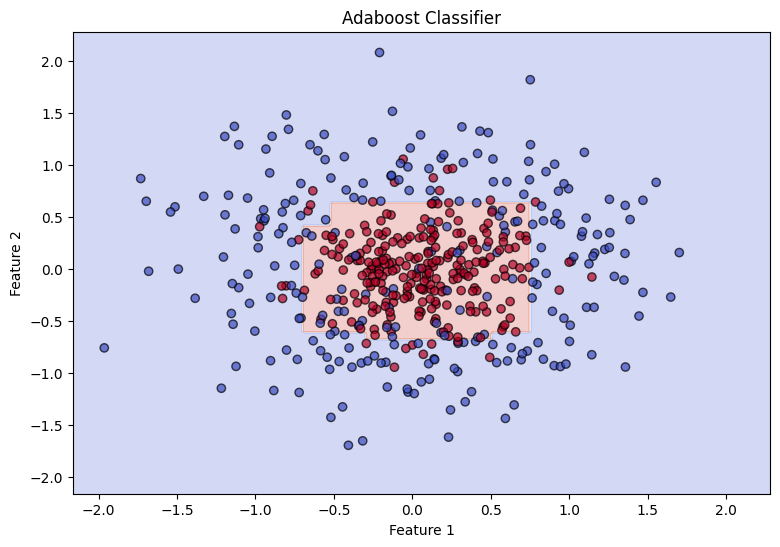

In [18]:
adabost_classifier2 = AdaBoostClassifier(n_estimators=500,learning_rate=0.1,random_state=22)
adabost_classifier2.fit(X,y)

adabost_classifier2_pre = accuracy_score(y, adabost_classifier2.predict(X))
print(f"adabost_classifier2 training accuracy: {adabost_classifier2_pre:.4f}")
plot_decision_boundary(adabost_classifier2)